# Exploration plotting
The purpose of this notebook is to plot exploration behaviour. We do that by plotting the number of actions explored per turn and the proportion of greedy pulls per turn

## Setup

In [4]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd


In [5]:
# Move up to main repo directory
import os
os.chdir("../..") # ONLY RUN THIS ONCE

In [6]:
## Load CSV file from file path string

def load_csv(file_path):
    """Load a CSV file and return a pandas DataFrame."""
    try:
        df = pd.read_csv(file_path)
        print(f"Loaded CSV file: {file_path}")
        return df
    except Exception as e:
        print(f"Error loading CSV file: {e}")
        return None

### Lookup Maps for Plots

In [7]:
rewards_per_scale = {
    'high_scale': [75,50,25],
    'low_scale': [0.75,0.5,0.25],
    'high_neg_scale': [-25, -50, -75],
    'low_neg_scale': [-0.25, -0.5, -0.75]
}

## Plotting

In [11]:
def plot_metric_with_std(input_df, metric_name, subplot_col, legend_col, title="Please Add a Title", include_std=True):
    """
    Plot a line graph with mean and standard deviation for a given metric, creating a 2x2 grid of subplots with positions specified by magnitudes.
    Places a single legend for the entire plot to the right, avoiding overlap with subplots.

    Args:
        input_df (pd.DataFrame): The input DataFrame containing the data to plot.
        metric_name (str): The metric name to plot (e.g., 'reward', 'regret'). 
        subplot_col (str): The column to use to separate the rows between subplots (should be 'scale').
        legend_col (str): The column to use to label the rows in each subplot.
        title (str): The title for the entire figure.
        include_std (bool): Whether to include the std shaded area.

    Returns:
        None
    """

    ###############
    # Styling constants and such
    ###############

    STYLE_CONSTANTS = {
        'max_val': {
            'linestyle': '--',
            'color': 'black',
            'label': 'Maximum',
        },
        'min_val': {
            'linestyle': '--',
            'color': 'firebrick',
            'label': 'Minimum',
        },
        'alphanumeric': {
            'linestyle': '-',
            'color': 'blue',
            'label': 'Alphanumeric',
            'marker': 'o',
        },
        'sem_rel_helpful': {
            'linestyle': '-',
            'color': 'darkgreen',
            'label': 'Relevant - Helpful',
            'marker': '^',
        },
        'sem_rel_mislead': {
            'linestyle': '-',
            'color': 'firebrick',
            'label': 'Relevant - Misleading',
            'marker': 'v',
        },
        'sent_helpful': {
            'linestyle': '-',
            'color': 'palegreen',
            'label': 'Sentiment - Helpful',
            'marker': '^',
        },
        'sent_mislead': {
            'linestyle': '-',
            'color': 'coral',
            'label': 'Sentiment - Misleading',
            'marker': 'v',
        },

    }


    # Hardcoded 2x2 grid based on magnitudes
    magnitudes = [['high_scale', 'low_scale'],
                  ['high_neg_scale', 'low_neg_scale']]

    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
    fig.suptitle(title, fontsize=16)

    # Collect all legend handles/labels
    all_handles = []
    all_labels = []
    legend_labels_set = set()

    for i in range(2):
        for j in range(2):
            ax = axes[i, j]
            subplot_kwd = magnitudes[i][j]
            filtered_df = input_df[input_df[subplot_col].str.contains(subplot_kwd, na=False)].copy()

            try:
                filtered_df['legend'] = filtered_df[legend_col]
            except ValueError as e:
                print(e)
                continue

            turn_numbers = sorted(
                int(col.split('_')[-2]) for col in input_df.columns 
                if col.startswith(f"{metric_name}_") and col.endswith("_mean")
            )

            for legend_label in filtered_df['legend'].unique():
                legend_df = filtered_df[filtered_df['legend'] == legend_label]
                means = legend_df[[f"{metric_name}_{turn}_mean" for turn in turn_numbers]].values.flatten()
                stds = legend_df[[f"{metric_name}_{turn}_std" for turn in turn_numbers]].values.flatten()

                try:
                    handle, = ax.plot(turn_numbers, means, **STYLE_CONSTANTS[legend_label])
                    if legend_label not in legend_labels_set:
                        all_handles.append(handle)
                        all_labels.append(legend_label)
                        legend_labels_set.add(legend_label)
                except Exception as e:
                    print(f"ERROR: {legend_label} {subplot_kwd} {turn_numbers} {means} {filtered_df} {legend_df}", e)

                if include_std:
                    ax.fill_between(turn_numbers, means - stds, means + stds, alpha=0.2)

            if subplot_kwd in rewards_per_scale:
                scale_rewards = rewards_per_scale[subplot_kwd]
                if metric_name == 'cum_regret':
                    max_regret = max(scale_rewards) - min(scale_rewards)
                    regret_lists = {}
                    regret_lists['max_val'] = [max_regret * i for i in range(1, len(turn_numbers) + 1)]
                    regret_lists['min_val'] = [0.0] * len(turn_numbers)
                    
                    # Plot and add to legend handler
                    for metric_key in regret_lists.keys():
                        handle, = ax.plot(turn_numbers, regret_lists[metric_key], **STYLE_CONSTANTS[metric_key])
                        if STYLE_CONSTANTS[metric_key]['label'] not in legend_labels_set:
                            all_handles.append(handle)
                            all_labels.append(STYLE_CONSTANTS[metric_key]['label'])
                            legend_labels_set.add(STYLE_CONSTANTS[metric_key]['label'])
                elif metric_name == 'cum_reward':
                    reward_vals = {
                        'max_val': max(scale_rewards),
                        'min_val': min(scale_rewards)
                    }
                    for key in reward_vals.keys():
                        reward_list = [reward_vals[key] * i for i in range(1, len(turn_numbers) + 1)]
                        ax.plot(turn_numbers, reward_list, label=STYLE_CONSTANTS[key]['label'], color=STYLE_CONSTANTS[key]['colour'], linestyle=STYLE_CONSTANTS[key]['linestyle'])

            ax.set_title(f"{subplot_kwd.replace('_', ' ').capitalize()} {metric_name.capitalize()}")
            ax.set_xlabel("Turn")
            ax.set_ylabel(metric_name.capitalize())

    # Place a single legend for the whole figure to the right
    fig.legend(all_handles, all_labels, loc='center left', bbox_to_anchor=(0.85, 0.5), borderaxespad=0)
    plt.tight_layout(rect=[0, 0, 0.85, 0.96])
    plt.show()


## Jan 19 - Farm Main Results


Loaded CSV file: experiments/20260118_farm_novar/merged_eval_results.csv


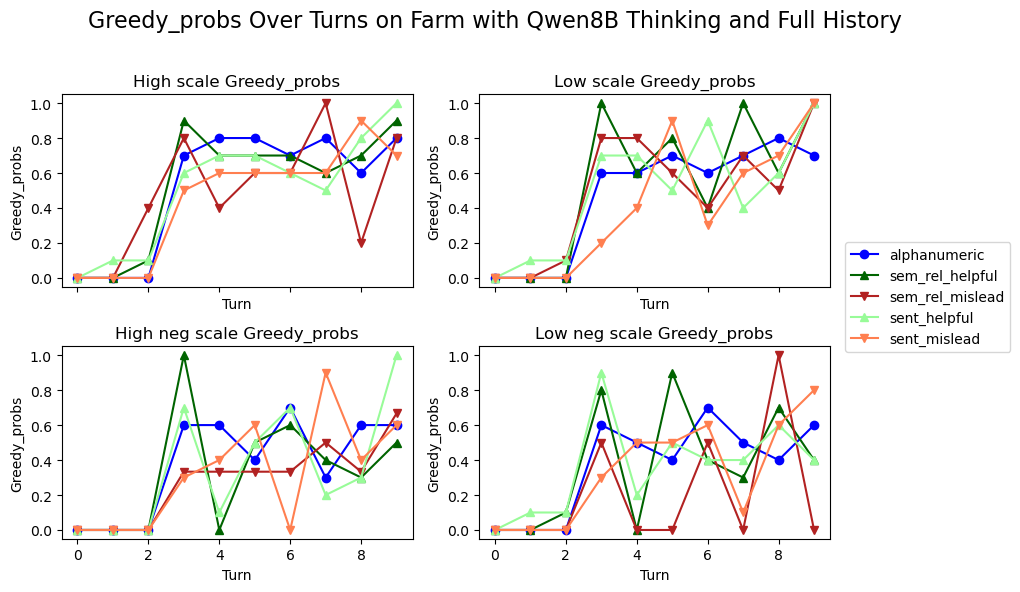

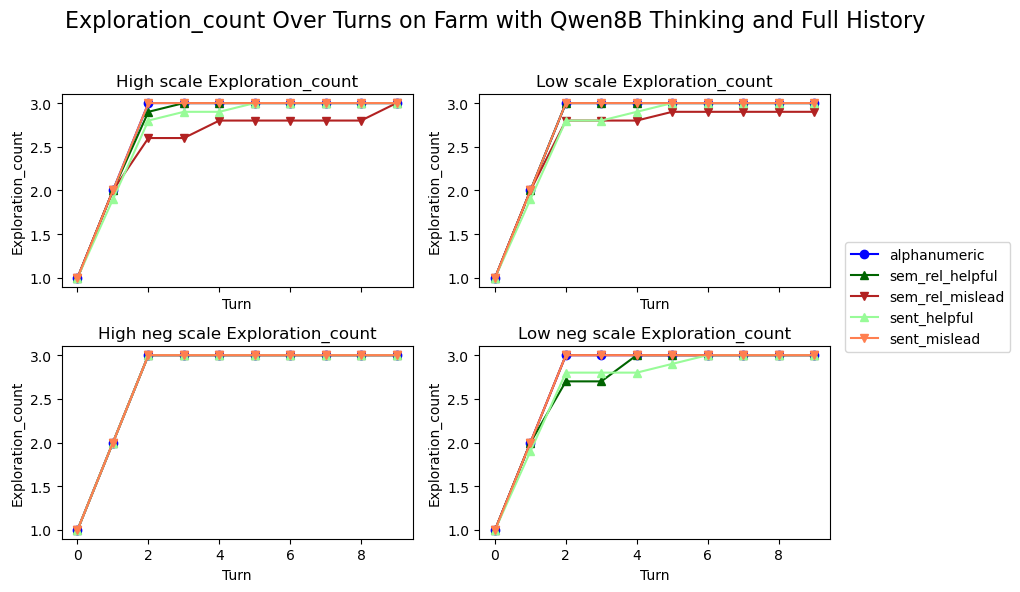

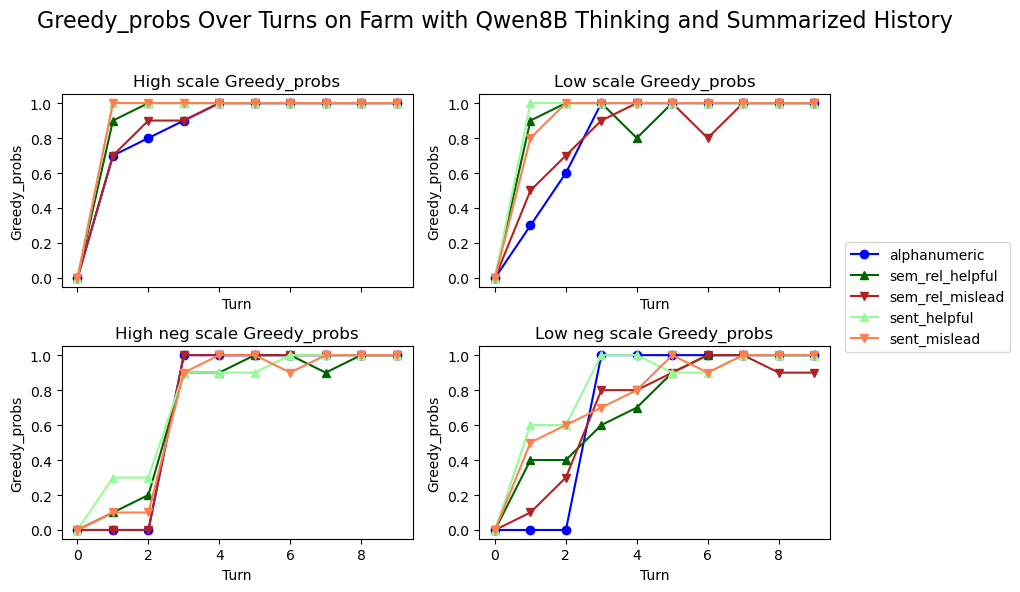

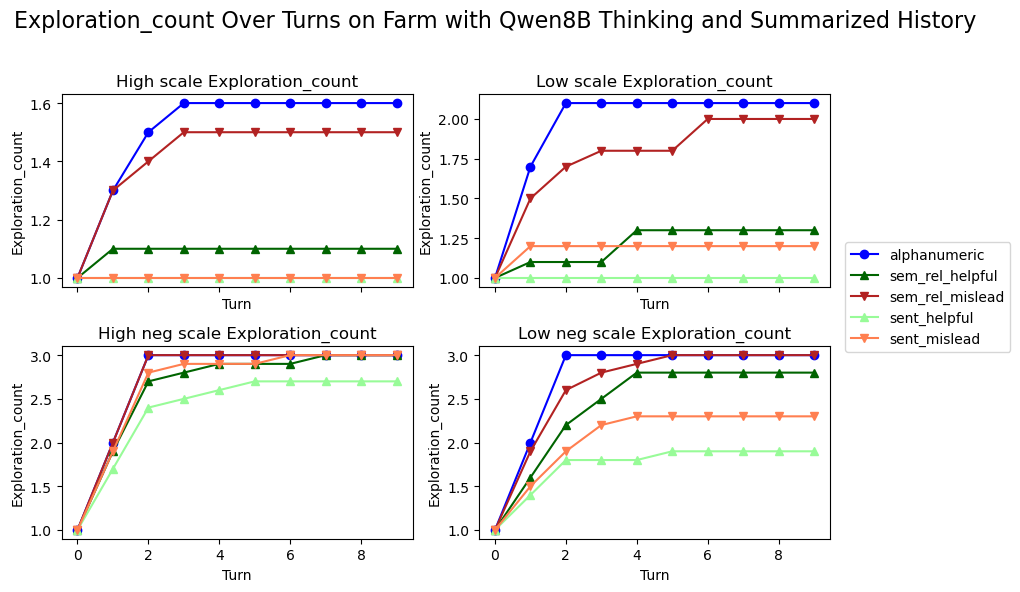

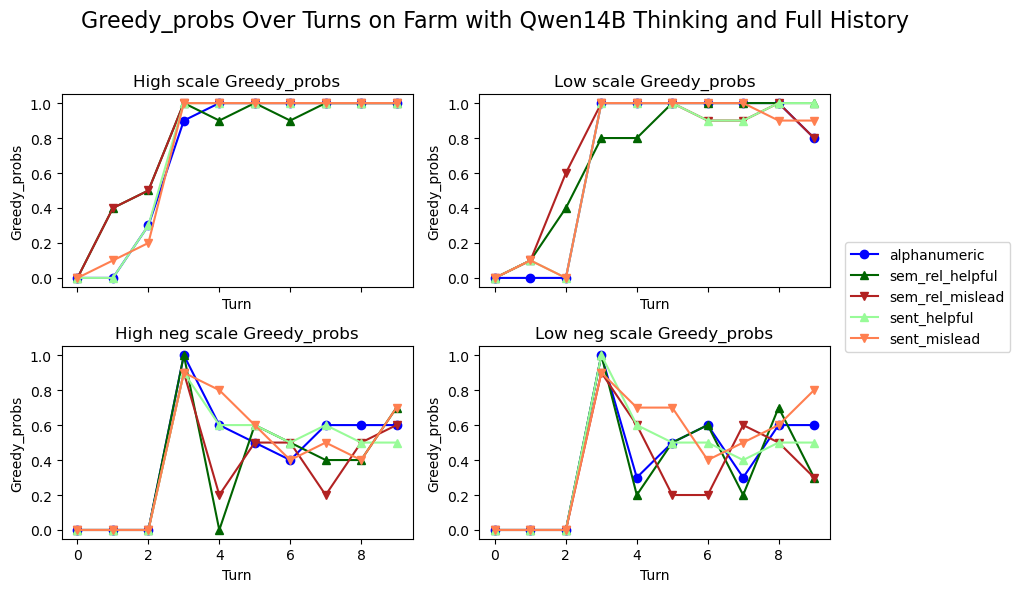

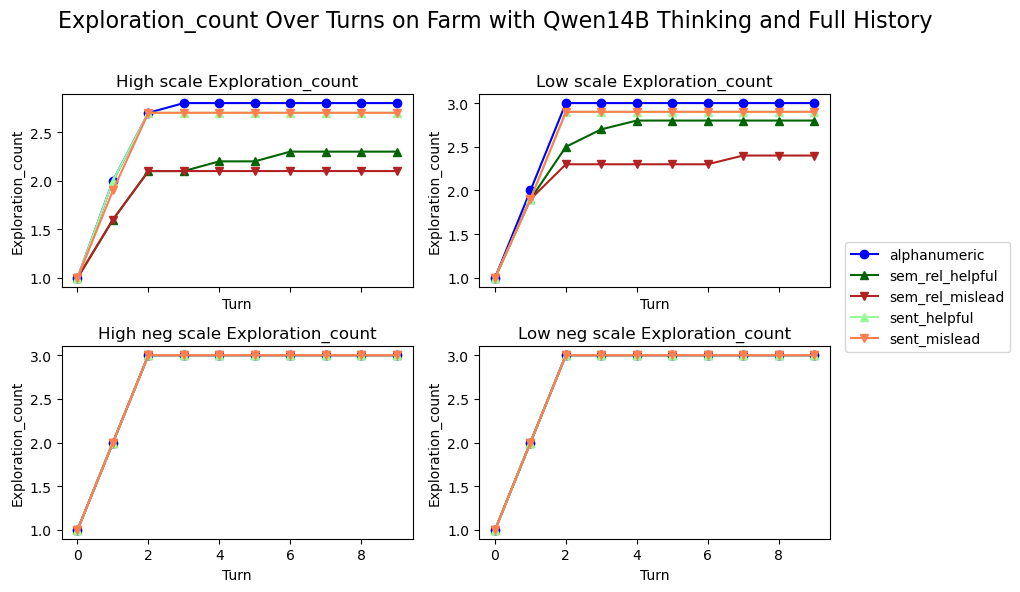

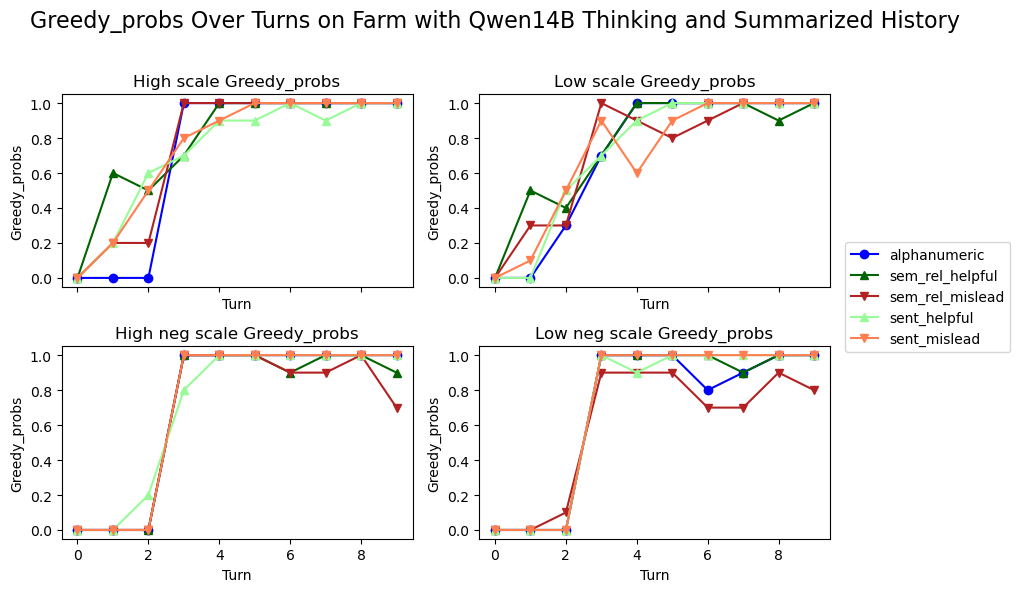

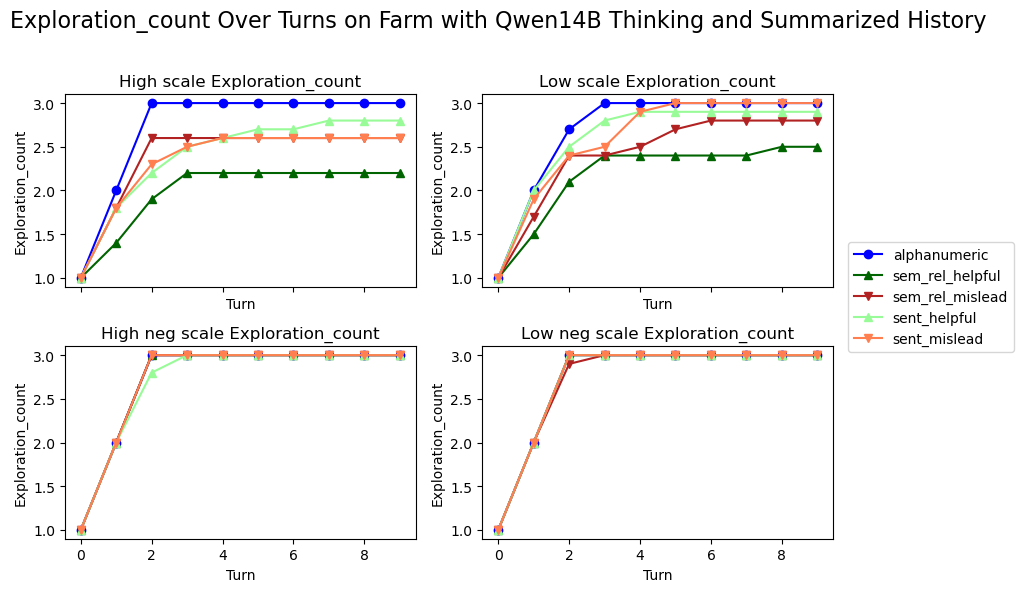

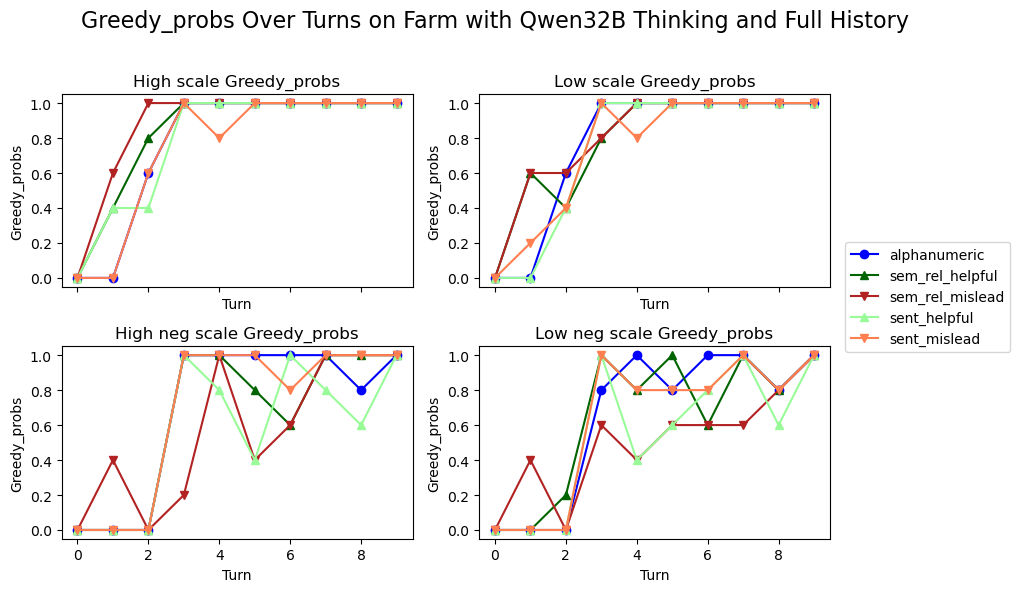

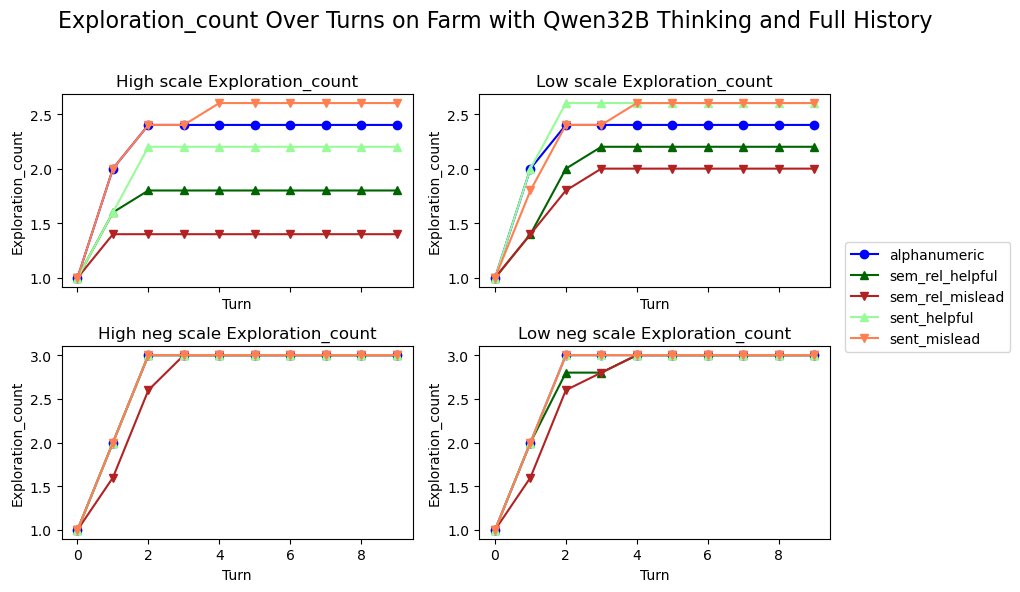

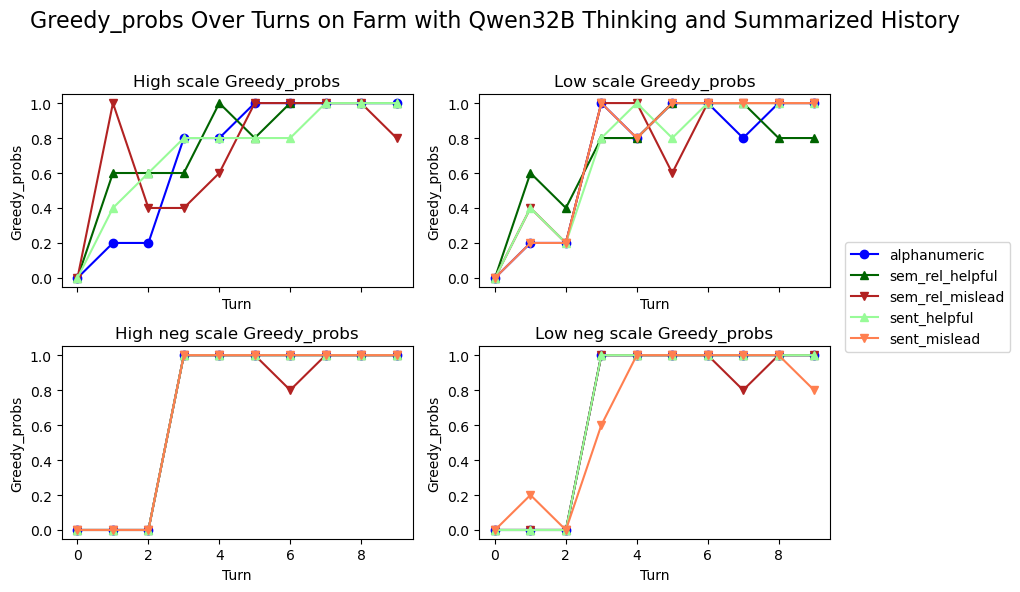

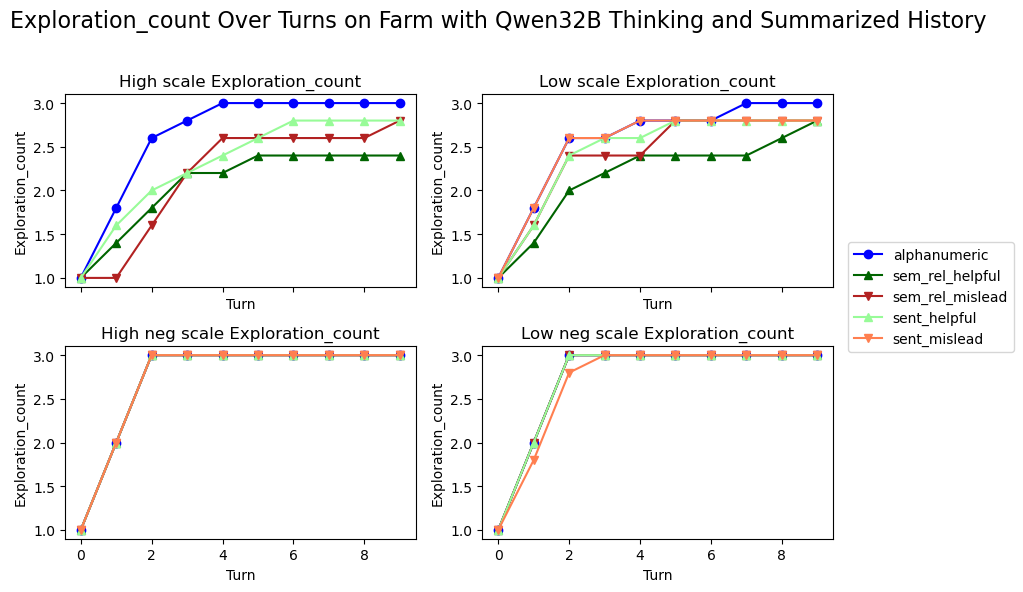

In [12]:
## First, we load in the merged dataframe
eval_path = 'experiments/20260118_farm_novar/merged_eval_results.csv'
results_df = load_csv(eval_path)

subplot_label = 'scale'
legend_label = 'nomenclature'

# metrics = ['cum_regret', 'sem_optimal_actions', 'reward_optimal_actions']
metrics = ['greedy_probs', 'exploration_count']

for model in results_df['Model'].unique():
    for hist in results_df['History'].unique():
        subset = results_df[(results_df['Model'] == model) & (results_df['History'] == hist)]
        for metric_key in metrics:
            title = f"{metric_key.capitalize()} Over Turns on Farm with {model} Thinking and {hist} History"
            plot_metric_with_std(subset, metric_key, subplot_label, legend_label, title, include_std=False)